## Customer Segmentation for E-Commerce

## Objective
**Segment customers based on purchasing behavior using RFM (Recency, Frequency, Monetary) analysis.**

## 🛠 Tech
- **Pandas**
- **KMeans**
- **Matplotlib**
- **Seaborn**

## 📂 Dataset
E-commerce transactions with:
- 🆔 **Customer_ID**
- 💰 **Purchase_Amount**
- 🗓 **Purchase_Date**

## 🔑 Key Insights
- 🔍 Identify **high-value customers** (loyal customers, frequent buyers)
- 📊 Visualize customer segmentation using **K-Means clustering**
- 📅 Find **seasonal shopping trends**

## 🎯 Use Case
Helps businesses **target customers with personalized offers.**

In [24]:
# importing the pandas

import pandas as pd
# creating a dataframe
df=pd.read_excel('ecommerce_transactions.xlsx')
# to display the data
df


,Customer_ID,Purchase_Amount,Purchase_Date
0,1102,403.71,2023-06-27 13:00:00
1,1435,465.32,2023-04-25 11:00:00
2,1348,208.50,2023-04-10 13:00:00
3,1270,453.99,2023-05-29 01:00:00
4,1106,167.53,2023-05-07 03:00:00
...,...,...,...
4995,1110,363.10,2023-04-18 22:00:00
4996,1414,255.15,2023-02-13 10:00:00
4997,1289,448.11,2023-04-16 18:00:00
4998,1294,460.74,2023-02-05 21:00:00


In [2]:
# to fetch the duplicate records for E-Commerce

duplicate_record=df[df.duplicated()]
print(duplicate_record)


Empty DataFrame
Columns: [Customer_ID, Purchase_Amount, Purchase_Date]
Index: []


In [4]:
# Display basic info and first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      5000 non-null   int64         
 1   Purchase_Amount  5000 non-null   float64       
 2   Purchase_Date    5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 117.3 KB


,Customer_ID,Purchase_Amount,Purchase_Date
0,1102,403.71,2023-06-27 13:00:00
1,1435,465.32,2023-04-25 11:00:00
2,1348,208.50,2023-04-10 13:00:00
3,1270,453.99,2023-05-29 01:00:00
4,1106,167.53,2023-05-07 03:00:00


In [9]:
# analysing the data for ecommerce
analysis_date=df['Purchase_Date'].max()

# RFM Calculation
rfm_df = df.groupby("Customer_ID").agg({
    "Purchase_Date": lambda x: (analysis_date - x.max()).days,  # Recency
    "Customer_ID": "count",  # Frequency
    "Purchase_Amount": "sum"  # Monetary
}).rename(columns={
    "Purchase_Date": "Recency",
    "Customer_ID": "Frequency",
    "Purchase_Amount": "Monetary"
}).reset_index()

rfm_df.head(10)

,Customer_ID,Recency,Frequency,Monetary
0,1000,5,14,4107.86
1,1001,54,10,2626.27
2,1002,37,9,2347.19
3,1003,24,10,2019.26
4,1004,7,15,3504.62
5,1005,30,4,1489.38
6,1006,17,11,3022.69
7,1007,3,14,3843.71
8,1008,29,9,2888.70
9,1009,1,9,2306.90


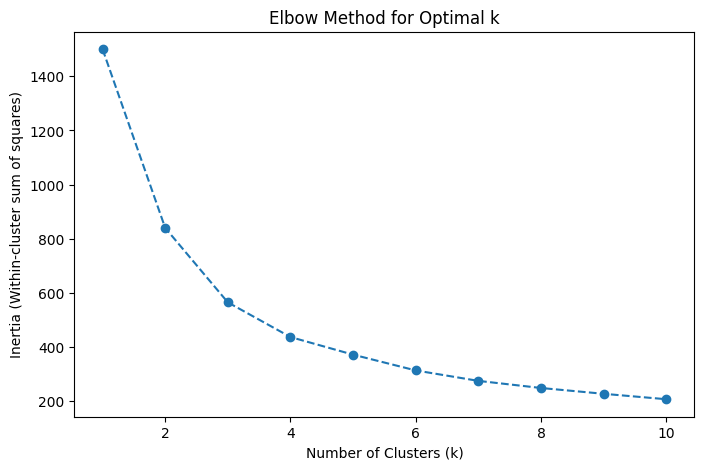

In [ ]:
# using the seaborne,matplotlib,standardscalerand sklearn.preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sb

# Normalize RFM values

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

# Determine optimal number of clusters using the Elbow method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.show()



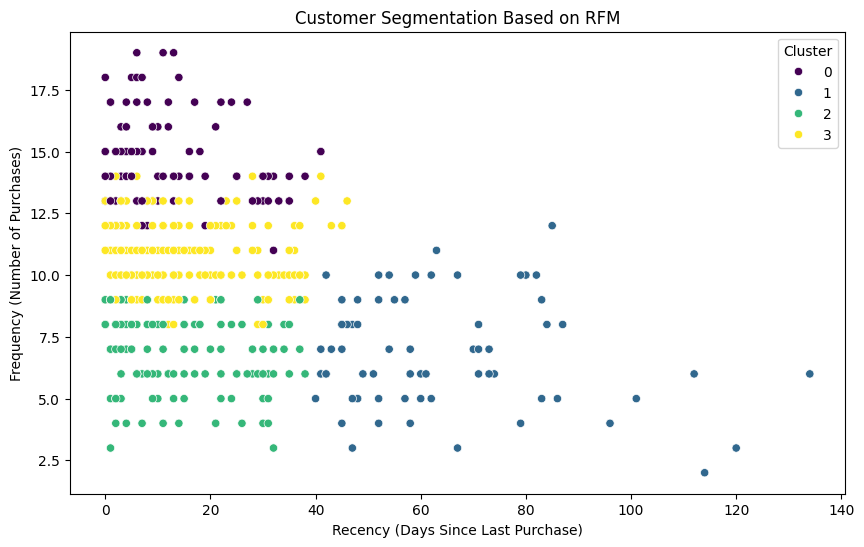

In [12]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Visualize the clusters using a scatter plot (Recency vs Frequency)
plt.figure(figsize=(10, 6))
sb.scatterplot(data=rfm_df, x="Recency", y="Frequency", hue=rfm_df["Cluster"], palette="viridis")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Frequency (Number of Purchases)")
plt.title("Customer Segmentation Based on RFM")
plt.legend(title="Cluster")
plt.show()


In [14]:
# Summarize each cluster by averaging RFM values
cluster_summary = rfm_df.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "Customer_ID": "count"
}).rename(columns={"Customer_ID": "Customer_Count"}).round(2)

# Display cluster summary
cluster_summary


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,12.12,14.66,3874.05,104
1,63.64,6.82,1672.40,67
2,14.39,6.79,1614.37,126
3,14.84,10.65,2672.91,203


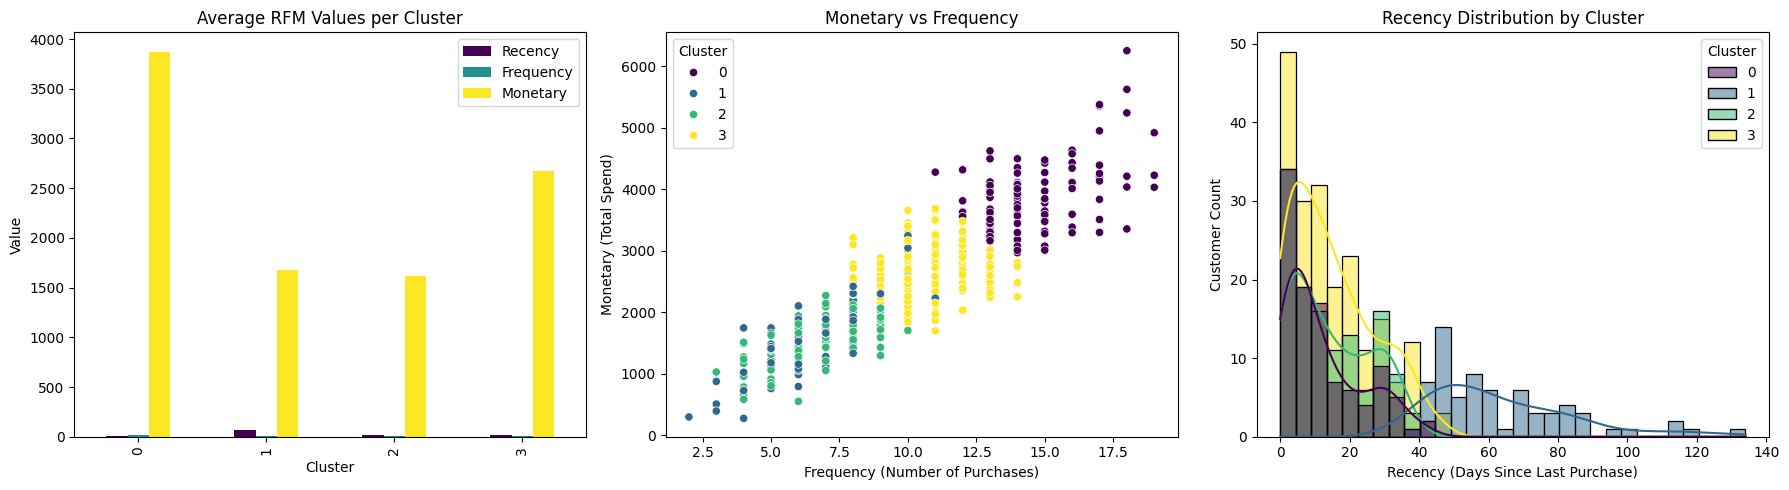

In [16]:
# Set up figure layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot for average RFM values per cluster
cluster_summary[['Recency', 'Frequency', 'Monetary']].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Average RFM Values per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Value')

# Scatter plot for Monetary vs Frequency
sb.scatterplot(data=rfm_df, x="Frequency", y="Monetary", hue="Cluster", palette="viridis", ax=axes[1])
axes[1].set_title('Monetary vs Frequency')
axes[1].set_xlabel('Frequency (Number of Purchases)')
axes[1].set_ylabel('Monetary (Total Spend)')

# Histogram for Recency distribution
sb.histplot(rfm_df, x="Recency", hue="Cluster", kde=True, palette="viridis", bins=30, ax=axes[2])
axes[2].set_title('Recency Distribution by Cluster')
axes[2].set_xlabel('Recency (Days Since Last Purchase)')
axes[2].set_ylabel('Customer Count')

# Show plots
plt.tight_layout()
plt.show()


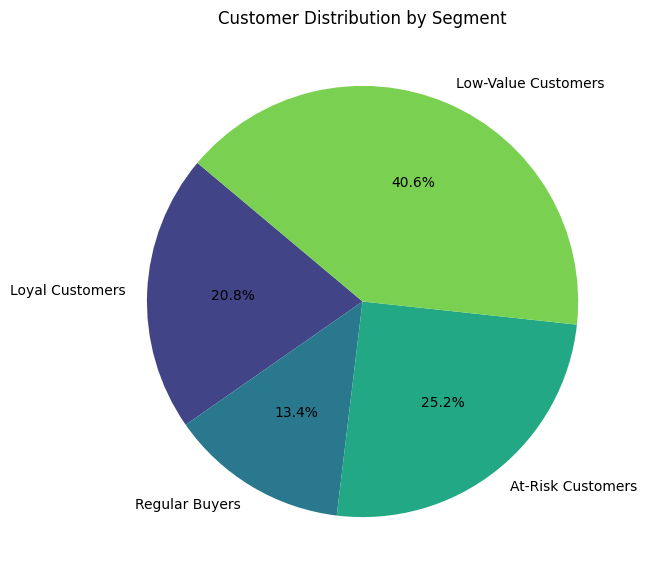

,Recency,Frequency,Monetary,Customer_Count,Segment_Name
Cluster,,,,,
0,12.12,14.66,3874.05,104,Loyal Customers
1,63.64,6.82,1672.40,67,Regular Buyers
2,14.39,6.79,1614.37,126,At-Risk Customers
3,14.84,10.65,2672.91,203,Low-Value Customers


In [20]:
# Define cluster names
cluster_labels = {
    0: "Loyal Customers",
    1: "Regular Buyers",
    2: "At-Risk Customers",
    3: "Low-Value Customers"
}

# Map cluster numbers to names
cluster_summary["Segment_Name"] = cluster_summary.index.map(cluster_labels)

# Pie chart with names
plt.figure(figsize=(7, 7))
plt.pie(cluster_summary["Customer_Count"], labels=cluster_summary["Segment_Name"], autopct='%1.1f%%', 
        colors=sb.color_palette("viridis", len(cluster_summary)), startangle=140)
plt.title("Customer Distribution by Segment")
plt.show()

# Display updated cluster summary
cluster_summary
